# фильтрация артефактов ЭМГ

## импорты

In [49]:
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from scipy import linalg, signal
from scipy.signal import find_peaks

mne.set_log_level("WARNING")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True


## пути

In [50]:
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

data_raw_dir = project_root / "data" / "raw"
data_processed_dir = project_root / "data" / "processed"
figures_dir = project_root / "outputs" / "figures"
qc_dir = project_root / "outputs" / "qc"

for folder in [data_raw_dir, data_processed_dir, figures_dir, qc_dir]:
    folder.mkdir(parents=True, exist_ok=True)

fif_path = data_raw_dir / "raw_artefacts_emg.fif"
annotations_path = qc_dir / "raw_base-annot.fif"
legacy_annotations_path = qc_dir / "raw_base_annotations.csv"

# пути для ручного запуска
# fif_path = Path(r"/Users/user/Desktop/raw_artefacts_emg.fif")
# fif_path = Path(r"C:\\Users\\user\\Desktop\\raw_artefacts_emg.fif")

print("Project root:", project_root)
print("Input FIF:", fif_path)
print("Processed:", data_processed_dir)
print("Figures:", figures_dir)
print("QC:", qc_dir)


Project root: /Users/user/Documents/emg_artifacts_filter
Input FIF: /Users/user/Documents/emg_artifacts_filter/data/raw/raw_artefacts_emg.fif
Processed: /Users/user/Documents/emg_artifacts_filter/data/processed
Figures: /Users/user/Documents/emg_artifacts_filter/outputs/figures
QC: /Users/user/Documents/emg_artifacts_filter/outputs/qc


## загрузка данных

In [51]:
if not fif_path.exists():
    raise FileNotFoundError(f"Файл не найден: {fif_path}")

raw_original = mne.io.read_raw_fif(fif_path, preload=True)
raw_base = raw_original.copy()

# восстанавливаем сохранённую разметку при повторном запуске
if annotations_path.exists():
    saved_annotations = mne.read_annotations(annotations_path)
    raw_base.set_annotations(saved_annotations)
    annotations_source = annotations_path
elif legacy_annotations_path.exists():
    # преобразуем onset старого CSV из времени Unix в секунды записи
    annotations_table = pd.read_csv(legacy_annotations_path)
    epoch = pd.Timestamp("1970-01-01", tz="UTC")
    annotation_onsets = (
        pd.to_datetime(annotations_table["onset"], utc=True) - epoch
    ).dt.total_seconds().to_numpy()
    saved_annotations = mne.Annotations(
        onset=annotation_onsets,
        duration=annotations_table["duration"].to_numpy(),
        description=annotations_table["description"].astype(str).to_numpy(),
        orig_time=None,
    )
    raw_base.set_annotations(saved_annotations)
    annotations_source = legacy_annotations_path
else:
    annotations_source = None

sfreq = raw_base.info["sfreq"]
duration_s = raw_base.n_times / sfreq

print("File:", fif_path.name)
print("Channels:", len(raw_base.ch_names))
print("sfreq:", sfreq)
print("Duration, s:", round(duration_s, 2))
print("First channels:", raw_base.ch_names[:10])
print("Annotations:", len(raw_base.annotations))
print("Annotations loaded from:", annotations_source or "input FIF")


/var/folders/sw/007c5hsj5zggxfp7nts4rq2w0000gn/T/ipykernel_48492/3011246944.py:5: RuntimeWarning: This filename (/Users/user/Documents/emg_artifacts_filter/data/raw/raw_artefacts_emg.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_original = mne.io.read_raw_fif(fif_path, preload=True)


File: raw_artefacts_emg.fif
Channels: 8
sfreq: 4000.0
Duration, s: 117.52
First channels: ['RF R', 'BF R', 'TA R', 'GM R', 'RF L', 'BF L', 'TA L', 'GM L']
Annotations: 19
Annotations loaded from: /Users/user/Documents/emg_artifacts_filter/outputs/qc/raw_base-annot.fif


## проверка записи

In [52]:
channels_table = pd.DataFrame(
    {
        "channel": raw_base.ch_names,
        "type": raw_base.get_channel_types(),
        "bad": [ch in raw_base.info["bads"] for ch in raw_base.ch_names],
    }
)

display(channels_table)
print(f"Sampling rate: {raw_base.info['sfreq']} Hz")
print(f"Duration: {duration_s:.2f} s")
print("Bad channels:", raw_base.info["bads"] or "none")

raw_base.plot()


,channel,type,bad
0,RF R,eeg,False
1,BF R,eeg,False
2,TA R,eeg,False
3,GM R,eeg,False
4,RF L,eeg,False
5,BF L,eeg,False
6,TA L,eeg,False
7,GM L,eeg,False


Sampling rate: 4000.0 Hz
Duration: 117.53 s
Bad channels: none


## сохранение аннотаций

In [53]:

raw_base.annotations.save(
    annotations_path,
    overwrite=True,
)

print(f"Сохранено аннотаций: {len(raw_base.annotations)}")
print("Файл:", annotations_path)

Сохранено аннотаций: 19
Файл: /Users/user/Documents/emg_artifacts_filter/outputs/qc/raw_base-annot.fif


## выбор каналов

In [54]:
emg_channels = ["GM R", "GM L", "RF R", "RF L", "TA R", "TA L", "BF R", "BF L"]
right_channels = ["GM R", "RF R", "TA R", "BF R"]
left_channels = ["GM L", "RF L", "TA L", "BF L"]

excluded_channels = ["TA L"]

print("EMG channels:", emg_channels)
print("Right:", right_channels)
print("Left:", left_channels)
print("Excluded:", excluded_channels)


EMG channels: ['GM R', 'GM L', 'RF R', 'RF L', 'TA R', 'TA L', 'BF R', 'BF L']
Right: ['GM R', 'RF R', 'TA R', 'BF R']
Left: ['GM L', 'RF L', 'TA L', 'BF L']
Excluded: ['TA L']


## CAR глобальный

In [55]:

car_channels = [ch for ch in emg_channels if ch not in excluded_channels]

raw_car_global = raw_base.copy()

avg = raw_car_global.get_data(picks=car_channels).mean(axis=0)
idx = [raw_car_global.ch_names.index(ch) for ch in car_channels]

raw_car_global._data[idx] -= avg

car_global_path = data_processed_dir / "recording_car_global_raw.fif"
raw_car_global.save(car_global_path, overwrite=True)

print("Saved:", car_global_path)
raw_car_global.plot()


Saved: /Users/user/Documents/emg_artifacts_filter/data/processed/recording_car_global_raw.fif


## CAR по сторонам

In [56]:

raw_car_left_right = raw_base.copy()

for channels in [right_channels, left_channels]:
    car_channels = [
        ch for ch in channels
        if ch not in excluded_channels
    ]

    avg = raw_car_left_right.get_data(picks=car_channels).mean(axis=0)
    idx = [raw_car_left_right.ch_names.index(ch) for ch in car_channels]

    raw_car_left_right._data[idx] -= avg

car_left_right_path = (
    data_processed_dir / "recording_car_left_right_raw.fif"
)
raw_car_left_right.save(car_left_right_path, overwrite=True)

print("Saved:", car_left_right_path)

raw_car_left_right.plot()


Saved: /Users/user/Documents/emg_artifacts_filter/data/processed/recording_car_left_right_raw.fif


## GED

In [57]:

GED_LABEL = "artifact"
GED_LOWPASS_HZ = 10.0  # частота среза
GED_BASELINE_S = 0.5  # длина фона
GED_GUARD_S = 0.05  # отступ от артефакта
GED_REGULARIZATION = 0.05  # регуляризация ковариации
GED_MIN_POWER_RATIO = 3.0  # порог мощности
GED_APPLY_BEFORE_S = 0.05  # расширение до артефакта
GED_APPLY_AFTER_S = 0.25  # расширение после артефакта
GED_FADE_S = 0.075  # длина плавного края

ged_channels = [
    ch for ch in emg_channels
    if ch not in excluded_channels
]

ged_model_path = qc_dir / "ged_artifact_model_and_masks.npz"
ged_output_path = data_processed_dir / "recording_ged_masked_raw.fif"

missing_channels = [
    ch for ch in ged_channels
    if ch not in raw_base.ch_names
]
if missing_channels:
    raise ValueError(f"В записи отсутствуют каналы: {missing_channels}")

print("GED channels:", ged_channels)
print("Excluded from GED:", excluded_channels)
print("Low-pass for artifact model, Hz:", GED_LOWPASS_HZ)


GED channels: ['GM R', 'GM L', 'RF R', 'RF L', 'TA R', 'BF R', 'BF L']
Excluded from GED: ['TA L']
Low-pass for artifact model, Hz: 10.0


### маски интервалов

In [58]:
artifact_mask = np.zeros(raw_base.n_times, dtype=bool)
apply_mask = np.zeros(raw_base.n_times, dtype=bool)
normal_mask = np.zeros(raw_base.n_times, dtype=bool)
artifact_intervals = []
apply_intervals = []

for annotation in raw_base.annotations:
    if GED_LABEL.lower() not in annotation["description"].lower():
        continue

    onset_from_start = annotation["onset"] - raw_base.first_time
    start = int(raw_base.time_as_index(onset_from_start, use_rounding=True)[0])
    stop = int(raw_base.time_as_index(
        onset_from_start + annotation["duration"], use_rounding=True
    )[0])
    start = max(0, start)
    stop = min(raw_base.n_times, max(start + 1, stop))

    artifact_mask[start:stop] = True
    artifact_intervals.append((start, stop))

if not artifact_mask.any():
    raise ValueError(f"Нет аннотаций с меткой {GED_LABEL!r}")

before = int(round(GED_APPLY_BEFORE_S * sfreq))
after = int(round(GED_APPLY_AFTER_S * sfreq))
for start, stop in artifact_intervals:
    apply_start = max(0, start - before)
    apply_stop = min(raw_base.n_times, stop + after)
    apply_mask[apply_start:apply_stop] = True
    apply_intervals.append((apply_start, apply_stop))

baseline = int(round(GED_BASELINE_S * sfreq))
guard = int(round(GED_GUARD_S * sfreq))
for apply_start, apply_stop in apply_intervals:
    normal_mask[max(0, apply_start - guard - baseline):max(0, apply_start - guard)] = True
    normal_mask[min(raw_base.n_times, apply_stop + guard):min(raw_base.n_times, apply_stop + guard + baseline)] = True
normal_mask &= ~apply_mask

print("Artifact intervals:", len(artifact_intervals))
print("Artifact duration, s:", round(artifact_mask.sum() / sfreq, 3))
print("Local normal EMG duration, s:", round(normal_mask.sum() / sfreq, 3))


Artifact intervals: 15
Artifact duration, s: 5.954
Local normal EMG duration, s: 15.0


### модель артефакта

In [43]:
X = raw_base.get_data(picks=ged_channels)
lowpass = signal.butter(
    4, GED_LOWPASS_HZ, btype="lowpass", fs=sfreq, output="sos"
)
X_slow = signal.sosfiltfilt(lowpass, X, axis=1)

# межканальная ковариация
def covariance(data):
    centered = data - data.mean(axis=1, keepdims=True)
    return centered @ centered.T / (centered.shape[1] - 1)

C_artifact = covariance(X_slow[:, artifact_mask])
C_normal = covariance(X_slow[:, normal_mask])
ridge = GED_REGULARIZATION * np.trace(C_normal) / len(ged_channels)
C_normal_reg = C_normal + ridge * np.eye(len(ged_channels))

eigenvalues, eigenvectors = linalg.eigh(C_artifact, C_normal_reg)
selected = eigenvalues > GED_MIN_POWER_RATIO
if not selected.any():
    raise ValueError("GED не нашёл компонент, специфичных для артефакта")
ged_filters = eigenvectors[:, selected]
components = ged_filters.T @ X_slow

# возвращаем компоненты в пространство каналов для построения модели артефакта
components_artifact = components[:, artifact_mask]
spatial_patterns = (
    X_slow[:, artifact_mask] @ components_artifact.T
    @ np.linalg.pinv(components_artifact @ components_artifact.T)
)
artifact_model = spatial_patterns @ components

eigenvalue_table = pd.DataFrame({
    "artifact / normal power": eigenvalues[::-1],
    "remove": selected[::-1],
})
display(eigenvalue_table)
display(pd.DataFrame(
    spatial_patterns, index=ged_channels,
    columns=[f"component {i + 1}" for i in range(selected.sum())],
))


,artifact / normal power,remove
0,288.826135,True
1,4.297219,True
2,1.065550,False
3,0.757080,False
4,0.456818,False
5,0.316367,False
6,0.225646,False


,component 1,component 2
GM R,-3.772748e-07,4.261030e-08
GM L,3.574541e-06,3.939770e-07
RF R,-4.657144e-07,-5.712046e-08
RF L,-2.990966e-06,1.750109e-07
TA R,-2.162619e-06,-4.284419e-05
BF R,3.776819e-05,-5.855152e-07
BF L,-4.114719e-06,-4.735509e-07


### вычитание компоненты

In [59]:
apply_weight = np.zeros(raw_base.n_times)
fade = int(round(GED_FADE_S * sfreq))
for start, stop in apply_intervals:
    length = stop - start
    edge = min(fade, length // 2)
    window = np.ones(length)
    if edge:
        ramp = 0.5 - 0.5 * np.cos(np.linspace(0, np.pi, edge))
        window[:edge] = ramp
        window[-edge:] = ramp[::-1]
    apply_weight[start:stop] = window

X_clean = X - artifact_model * apply_weight
raw_ged = raw_base.copy().load_data()
ged_indices = [raw_ged.ch_names.index(ch) for ch in ged_channels]
raw_ged._data[ged_indices] = X_clean

unchanged_outside = np.array_equal(
    raw_ged.get_data(picks=ged_channels)[:, ~apply_mask],
    X[:, ~apply_mask],
)
print("Outside annotations unchanged:", unchanged_outside)


Outside annotations unchanged: True


## SVD rank-1

In [ ]:
# обучаем SVD на тех же каналах и интервалах для сравнения с GED
svd_channels = ged_channels
X_svd = raw_base.get_data(picks=svd_channels)
X_svd_artifact = X_svd[:, artifact_mask]

svd_covariance = np.cov(X_svd_artifact)
U, svd_singular_values, Vt = np.linalg.svd(
    svd_covariance, full_matrices=False
)
U1 = U[:, [0]]  # главная компонента

# строим ортогональный проектор для удаления главной компоненты
svd_projector = np.eye(len(svd_channels)) - U1 @ U1.T

# применяем проектор только к размеченным отсчётам
X_svd_clean_artifact = svd_projector @ X_svd_artifact
raw_svd = raw_base.copy().load_data()
svd_indices = [raw_svd.ch_names.index(ch) for ch in svd_channels]
raw_svd._data[np.ix_(svd_indices, artifact_mask)] = X_svd_clean_artifact

svd_explained_fraction = (
    svd_singular_values[0] / svd_singular_values.sum()
)
print("First SVD covariance fraction:", round(svd_explained_fraction, 4))
print("Projector symmetric:", np.allclose(svd_projector, svd_projector.T))
print("Projector idempotent:", np.allclose(svd_projector @ svd_projector, svd_projector))
print("Outside annotations unchanged:", np.array_equal(
    raw_svd.get_data(picks=svd_channels)[:, ~artifact_mask],
    X_svd[:, ~artifact_mask],
))


## проверка сигнала

In [60]:
records = {
    "original": raw_base,
    "global CAR": raw_car_global,
    "left/right CAR": raw_car_left_right,
    "SVD rank-1 projector": raw_svd,
    "GED slow component": raw_ged,
}

rms_table = pd.DataFrame({
    name: np.sqrt(np.mean(
        record.get_data(picks=ged_channels)[:, artifact_mask] ** 2, axis=1
    ))
    for name, record in records.items()
}, index=ged_channels)
rms_table.index.name = "channel"
display(rms_table)

X_clean_slow = signal.sosfiltfilt(lowpass, X_clean, axis=1)
X_fast = X - X_slow
X_clean_fast = X_clean - X_clean_slow
quality = pd.Series({
    "slow RMS: artifact / local normal, before": np.sqrt(np.mean(X_slow[:, artifact_mask] ** 2)) / np.sqrt(np.mean(X_slow[:, normal_mask] ** 2)),
    "slow RMS: artifact / local normal, after": np.sqrt(np.mean(X_clean_slow[:, artifact_mask] ** 2)) / np.sqrt(np.mean(X_slow[:, normal_mask] ** 2)),
    "fast RMS after / before": np.sqrt(np.mean(X_clean_fast[:, artifact_mask] ** 2)) / np.sqrt(np.mean(X_fast[:, artifact_mask] ** 2)),
}, name="value")
display(quality.to_frame())


,original,global CAR,left/right CAR,GED slow component
channel,,,,
GM R,0.000093,0.000127,0.000220,0.000093
GM L,0.000079,0.000156,0.000084,0.000078
RF R,0.000213,0.000221,0.000236,0.000213
RF L,0.000568,0.000597,0.000512,0.000568
TA R,0.000760,0.000646,0.000570,0.000134
BF R,0.000169,0.000175,0.000207,0.000146
BF L,0.000436,0.000422,0.000485,0.000436


,value
"slow RMS: artifact / local normal, before",7.785815
"slow RMS: artifact / local normal, after",0.620167
fast RMS after / before,0.999099


## визуальное сравнение

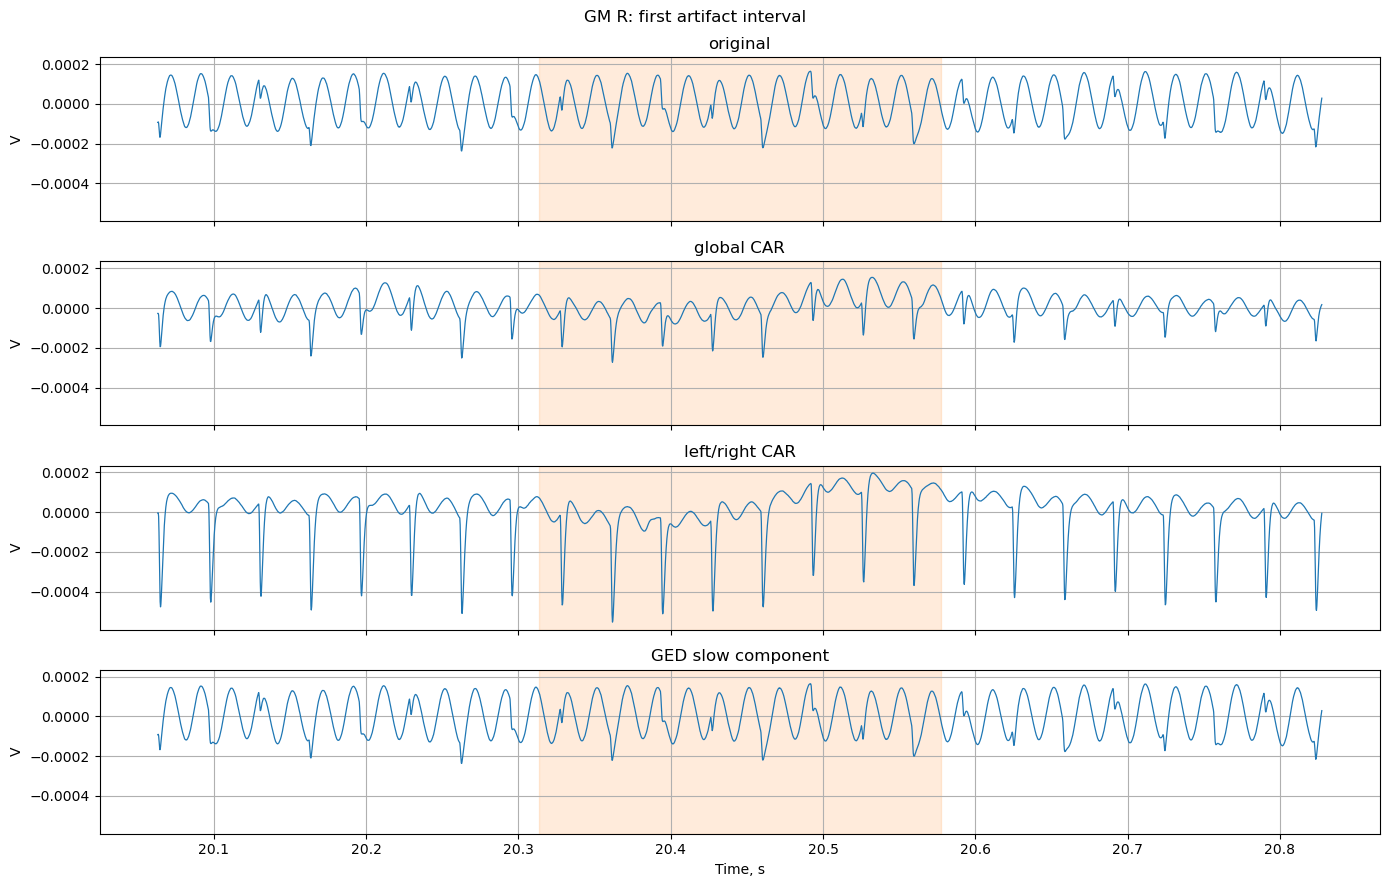

In [46]:
start, stop = artifact_intervals[0]
plot_channel = ged_channels[0]
context = int(round(0.25 * sfreq))
view_start = max(0, start - context)
view_stop = min(raw_base.n_times, stop + context)
time = raw_base.times[view_start:view_stop]

fig, axes = plt.subplots(len(records), 1, figsize=(14, 11), sharex=True, sharey=True)
for axis, (name, record) in zip(axes, records.items()):
    values = record.get_data(picks=[plot_channel])[0, view_start:view_stop]
    axis.plot(time, values, linewidth=0.9)
    axis.axvspan(raw_base.times[start], raw_base.times[stop - 1], color="tab:orange", alpha=0.15)
    axis.set_title(name)
    axis.set_ylabel("V")
axes[-1].set_xlabel("Time, s")
fig.suptitle(f"{plot_channel}: first artifact interval")
fig.tight_layout()
plt.show()


## сохранение результатов

In [61]:
raw_ged.save(ged_output_path, overwrite=True)
svd_output_path = data_processed_dir / "recording_svd_k1_masked_raw.fif"
svd_model_path = qc_dir / "svd_k1_model_and_mask.npz"
raw_svd.save(svd_output_path, overwrite=True)

np.savez(
    ged_model_path,
    channels=np.asarray(ged_channels),
    covariance_artifact=C_artifact,
    covariance_normal=C_normal,
    eigenvalues=eigenvalues,
    ged_filters=ged_filters,
    spatial_patterns=spatial_patterns,
    artifact_mask=artifact_mask,
    apply_mask=apply_mask,
    normal_mask=normal_mask,
    lowpass_hz=GED_LOWPASS_HZ,
)

np.savez(
    svd_model_path,
    channels=np.asarray(svd_channels),
    covariance=svd_covariance,
    singular_values=svd_singular_values,
    U1=U1,
    projector=svd_projector,
    artifact_mask=artifact_mask,
)

output_files = {
    "global CAR": car_global_path,
    "left/right CAR": car_left_right_path,
    "SVD rank-1 projector": svd_output_path,
    "GED slow component": ged_output_path,
}
for name, path in output_files.items():
    print(f"{name}: {path}")
print("GED model and masks:", ged_model_path)
print("SVD model and mask:", svd_model_path)


global CAR: /Users/user/Documents/emg_artifacts_filter/data/processed/recording_car_global_raw.fif
left/right CAR: /Users/user/Documents/emg_artifacts_filter/data/processed/recording_car_left_right_raw.fif
GED slow component: /Users/user/Documents/emg_artifacts_filter/data/processed/recording_ged_masked_raw.fif
GED model and masks: /Users/user/Documents/emg_artifacts_filter/outputs/qc/ged_artifact_model_and_masks.npz


## сравнение методов

### RMS

In [ ]:
comparison_channels = ged_channels
outside_mask = normal_mask.copy()  # локальные чистые интервалы
eps = np.finfo(float).eps

# среднеквадратичная амплитуда
def rms(x, axis=-1):
    return np.sqrt(np.mean(np.square(x), axis=axis))

X_before = raw_base.get_data(picks=comparison_channels)
artifact_rms_before = rms(X_before[:, artifact_mask], axis=1)
normal_rms_before = rms(X_before[:, outside_mask], axis=1)

metric_rows = []
channel_metrics = {}
for method, record in records.items():
    X_after = record.get_data(picks=comparison_channels)
    values = {
        "Artifact RMS": rms(X_after[:, artifact_mask], axis=1),
        "Local normal RMS": rms(X_after[:, outside_mask], axis=1),
        "Artifact RMS ratio": rms(X_after[:, artifact_mask], axis=1) / (artifact_rms_before + eps),
        "Local normal RMS ratio": rms(X_after[:, outside_mask], axis=1) / (normal_rms_before + eps),
    }
    channel_metrics[method] = pd.DataFrame(values, index=comparison_channels)
    for metric, vector in values.items():
        q1, median, q3 = np.nanpercentile(vector, [25, 50, 75])
        metric_rows.append({"method": method, "metric": metric, "median": median, "q1": q1, "q3": q3})

metrics_long = pd.DataFrame(metric_rows)
metrics_table = metrics_long.pivot(index="metric", columns="method", values=["median", "q1", "q3"])
metrics_display = metrics_long.assign(
    value=lambda d: d.apply(lambda r: f"{r['median']:.3f} [{r['q1']:.3f}–{r['q3']:.3f}]", axis=1)
).pivot(index="metric", columns="method", values="value")
display(metrics_display.reindex(list(channel_metrics["original"].columns)))


### сравнение до и после

In [ ]:
plot_channel = "TA R"  # канал для графика
method_records = {name: rec for name, rec in records.items() if name != "original"}
if not artifact_intervals:
    raise ValueError("Нет размеченных артефактов для визуализации")

# выбираем ближайшие артефакты для компактного сравнения
if len(artifact_intervals) > 1:
    pair_start = np.argmin([artifact_intervals[i + 1][0] - artifact_intervals[i][1] for i in range(len(artifact_intervals) - 1)])
    shown_intervals = artifact_intervals[pair_start:pair_start + 2]
else:
    shown_intervals = artifact_intervals[:1]
context = int(round(0.35 * sfreq))
view = slice(max(0, shown_intervals[0][0] - context), min(raw_base.n_times, shown_intervals[-1][1] + context))
t = raw_base.times[view]
before_view = raw_base.get_data(picks=[plot_channel])[0, view]
after_views = {name: rec.get_data(picks=[plot_channel])[0, view] for name, rec in method_records.items()}
all_signals = np.concatenate([before_view, *after_views.values()])
signal_limit = 1.05 * np.max(np.abs(all_signals))

fig, axes = plt.subplots(len(method_records), 1, figsize=(16, 3.1 * len(method_records)), sharex=True, sharey=True)
axes = np.atleast_1d(axes)
for ax, (method, after_view) in zip(axes, after_views.items()):
    ax.plot(t, before_view, color="#E63946", lw=1.6, alpha=0.95, label="before", zorder=3)
    ax.plot(t, after_view, color="#0066FF", lw=1.35, alpha=0.95, label="after", zorder=4)
    ax.set_ylim(-signal_limit, signal_limit)
    ax.set_ylabel("Amplitude, V")
    ax.set_title(method, loc="left", fontweight="bold")
    ax.grid(alpha=0.18)
    for start, stop in shown_intervals:
        ax.axvspan(raw_base.times[start], raw_base.times[stop - 1], color="#FFB000", alpha=0.22, zorder=1)
axes[0].legend(loc="upper right", frameon=True, ncol=2)
axes[-1].set_xlabel("Time, s")
fig.suptitle(f"{plot_channel}: before/after на размеченных артефактах", y=1.01)
fig.tight_layout()
plt.show()


### отношения RMS

In [ ]:
method_order = list(records)
artifact_heat = pd.DataFrame({m: channel_metrics[m]["Artifact RMS ratio"] for m in method_order}).T
normal_heat = pd.DataFrame({m: channel_metrics[m]["Local normal RMS ratio"] for m in method_order}).T

fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
for ax, table, title, cmap, limits in [
    (axes[0], artifact_heat, "Artifact RMS: after / before", "viridis", (0, max(1, np.nanpercentile(artifact_heat, 95)))),
    (axes[1], normal_heat, "Local normal RMS: after / before (идеал = 1)", "coolwarm", (0.5, 1.5)),
]:
    image = ax.imshow(table, aspect="auto", cmap=cmap, vmin=limits[0], vmax=limits[1])
    ax.set_xticks(range(len(table.columns)), table.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(table.index)), table.index)
    ax.set_title(title)
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            ax.text(j, i, f"{table.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8, color="black")
    fig.colorbar(image, ax=ax, shrink=0.85)
plt.show()


### межканальные корреляции

In [ ]:
corr_matrices = {
    method: np.corrcoef(record.get_data(picks=comparison_channels)[:, artifact_mask])
    for method, record in records.items()
}
fig, axes = plt.subplots(1, len(corr_matrices), figsize=(4.2 * len(corr_matrices), 4.3), constrained_layout=True)
for ax, (method, matrix) in zip(axes, corr_matrices.items()):
    image = ax.imshow(matrix, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(method)
    ax.set_xticks(range(len(comparison_channels)), comparison_channels, rotation=90)
    ax.set_yticks(range(len(comparison_channels)), comparison_channels)
fig.colorbar(image, ax=axes, shrink=0.75, label="Pearson r")
fig.suptitle("Межканальная корреляция внутри размеченных артефактов")
plt.show()

# вычитаем исходную матрицу для оценки изменения корреляций
fig, axes = plt.subplots(1, len(corr_matrices) - 1, figsize=(4.2 * (len(corr_matrices) - 1), 4.3), constrained_layout=True)
delta_limit = max(np.max(np.abs(m - corr_matrices["original"])) for name, m in corr_matrices.items() if name != "original")
for ax, (method, matrix) in zip(axes, [(n, m) for n, m in corr_matrices.items() if n != "original"]):
    delta = matrix - corr_matrices["original"]
    image = ax.imshow(delta, cmap="coolwarm", vmin=-delta_limit, vmax=delta_limit)
    ax.set_title(method)
    ax.set_xticks(range(len(comparison_channels)), comparison_channels, rotation=90)
    ax.set_yticks(range(len(comparison_channels)), comparison_channels)
fig.colorbar(image, ax=axes, shrink=0.75, label=r"$\Delta$ Pearson r")
fig.suptitle("Изменение корреляции относительно original")
plt.show()


## просмотр результата

In [ ]:
raw_ged.plot()